In [ ]:
import pandas as pd
import numpy as np


import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import (
    GroupShuffleSplit,
    GroupKFold,
    cross_validate
)

from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    multilabel_confusion_matrix
)


from sklearn.impute import SimpleImputer


from sklearn.pipeline import Pipeline


import joblib

import warnings
warnings.filterwarnings("ignore")

In [2]:
DATA_PATH = r"D:\Advisory model\mango_advisory_training_dataset_v2.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

Dataset shape: (486000, 30)

Columns:
['_soil_profile_id', 'city', 'country', 'latitude', 'longitude', 'elevation', 'year', 'month', 'N', 'P', 'K', 'ph', 'annual_temperature_c', 'annual_rainfall_mm', 'annual_et0_mm', 'monthly_temperature_c', 'monthly_rainfall_mm', 'monthly_precipitation_mm', 'monthly_et0_mm', 'monthly_wind_max_kmh', 'monthly_radiation', 'precipitation_hours', 'water_balance_mm', 'suitability', 'planting_period', 'irrigation_need', 'drought_risk', 'nutrient_condition', 'label_source', 'data_type']

First 5 rows:


,_soil_profile_id,city,country,latitude,longitude,elevation,year,month,N,P,...,monthly_radiation,precipitation_hours,water_balance_mm,suitability,planting_period,irrigation_need,drought_risk,nutrient_condition,label_source,data_type
0,1,Athurugiriya,Sri Lanka,6.900002,79.899994,27.0,2010,1,2,40,...,19.722903,47.0,-101.52,Not Suitable,Less Suitable,High,Moderate,Deficient,Rule-derived from mango dataset + Sri Lanka we...,synthetic_integrated_training_record
1,1,Athurugiriya,Sri Lanka,6.900002,79.899994,27.0,2010,2,2,40,...,20.291429,60.0,-84.29,Not Suitable,Less Suitable,High,Moderate,Deficient,Rule-derived from mango dataset + Sri Lanka we...,synthetic_integrated_training_record
2,1,Athurugiriya,Sri Lanka,6.900002,79.899994,27.0,2010,3,2,40,...,22.213548,118.0,-91.46,Not Suitable,Less Suitable,High,High,Deficient,Rule-derived from mango dataset + Sri Lanka we...,synthetic_integrated_training_record
3,1,Athurugiriya,Sri Lanka,6.900002,79.899994,27.0,2010,4,2,40,...,18.737000,283.0,151.55,Not Suitable,Possible with irrigation/management,Low,Low,Deficient,Rule-derived from mango dataset + Sri Lanka we...,synthetic_integrated_training_record
4,1,Athurugiriya,Sri Lanka,6.900002,79.899994,27.0,2010,5,2,40,...,15.418710,449.0,189.01,Not Suitable,Possible with irrigation/management,Low,Low,Deficient,Rule-derived from mango dataset + Sri Lanka we...,synthetic_integrated_training_record


In [3]:
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nData types:")
print(df.dtypes)

print("\nNumerical statistics:")
display(df.describe().T)

Missing values:
_soil_profile_id            0
city                        0
country                     0
latitude                    0
longitude                   0
elevation                   0
year                        0
month                       0
N                           0
P                           0
K                           0
ph                          0
annual_temperature_c        0
annual_rainfall_mm          0
annual_et0_mm               0
monthly_temperature_c       0
monthly_rainfall_mm         0
monthly_precipitation_mm    0
monthly_et0_mm              0
monthly_wind_max_kmh        0
monthly_radiation           0
precipitation_hours         0
water_balance_mm            0
suitability                 0
planting_period             0
irrigation_need             0
drought_risk                0
nutrient_condition          0
label_source                0
data_type                   0
dtype: int64

Duplicate rows: 0

Data types:
_soil_profile_id              int64
cit

,count,mean,std,min,25%,50%,75%,max
_soil_profile_id,486000.0,50.500000,28.866100,1.000000,25.750000,50.500000,75.250000,100.000000
latitude,486000.0,7.123334,0.798618,6.000000,6.800003,6.900002,7.400002,9.700005
longitude,486000.0,80.263335,0.488870,79.800020,79.899994,80.000000,80.399994,81.800020
elevation,486000.0,111.733333,266.380195,0.000000,7.000000,14.000000,27.000000,1281.000000
year,486000.0,2016.259259,3.902450,2010.000000,2013.000000,2016.000000,2020.000000,2023.000000
month,486000.0,6.388889,3.450267,1.000000,3.000000,6.000000,9.000000,12.000000
N,486000.0,20.070000,12.267249,0.000000,9.000000,21.000000,30.250000,40.000000
P,486000.0,27.180000,7.625465,15.000000,19.750000,27.500000,35.000000,40.000000
K,486000.0,29.920000,3.081172,25.000000,27.000000,30.000000,32.000000,35.000000
ph,486000.0,5.766373,0.700128,4.507524,5.183736,5.743385,6.416573,6.967418


In [4]:
print("Unique cities:", df["city"].nunique())
print("Unique years:", df["year"].nunique())
print("Unique months:", df["month"].nunique())

Unique cities: 30
Unique years: 14
Unique months: 12


In [5]:
targets = [
    "suitability",
    "irrigation_need",
    "drought_risk",
    "nutrient_condition"
]

for target in targets:
    print("\n" + "="*60)
    print(target)
    print(df[target].value_counts())
    print("\nPercentage:")
    print(
        (df[target].value_counts(normalize=True) * 100)
        .round(2)
    )


suitability
suitability
Not Suitable           249120
Moderately Suitable    161280
Suitable                75600
Name: count, dtype: int64

Percentage:
suitability
Not Suitable           51.26
Moderately Suitable    33.19
Suitable               15.56
Name: proportion, dtype: float64

irrigation_need
irrigation_need
Low         295300
High        121200
Moderate     69500
Name: count, dtype: int64

Percentage:
irrigation_need
Low         60.76
High        24.94
Moderate    14.30
Name: proportion, dtype: float64

drought_risk
drought_risk
Low         369100
High         75400
Moderate     41500
Name: count, dtype: int64

Percentage:
drought_risk
Low         75.95
High        15.51
Moderate     8.54
Name: proportion, dtype: float64

nutrient_condition
nutrient_condition
Deficient               233280
Moderately Deficient    150660
Adequate                102060
Name: count, dtype: int64

Percentage:
nutrient_condition
Deficient               48.0
Moderately Deficient    31.0
Adequate   

In [6]:
FEATURES = [
    "N",
    "P",
    "K",
    "ph",

    "annual_temperature_c",
    "annual_rainfall_mm",
    "annual_et0_mm",

    "monthly_temperature_c",
    "monthly_rainfall_mm",
    "monthly_et0_mm",

    "monthly_wind_max_kmh",
    "monthly_radiation",
    "precipitation_hours",

    "water_balance_mm",

    "elevation",
    "month"
]

In [7]:
TARGETS = [
    "suitability",
    "irrigation_need",
    "drought_risk",
    "nutrient_condition"
]

In [ ]:

df.replace([np.inf, -np.inf], np.nan, inplace=True)


df = df[
    (df["ph"] > 0) &
    (df["N"] >= 0) &
    (df["P"] >= 0) &
    (df["K"] >= 0) &
    (df["annual_rainfall_mm"] >= 0) &
    (df["monthly_rainfall_mm"] >= 0) &
    (df["annual_et0_mm"] >= 0) &
    (df["monthly_et0_mm"] >= 0)
].copy()

print("Remaining records:", len(df))

Remaining records: 486000


In [9]:
df["temperature_range"] = (
    df["annual_temperature_c"]
)

df["monthly_water_deficit"] = (
    df["monthly_et0_mm"] -
    df["monthly_rainfall_mm"]
)

df["rainfall_et0_ratio"] = (
    df["monthly_rainfall_mm"] /
    (df["monthly_et0_mm"] + 1e-6)
)

df["annual_rainfall_et0_ratio"] = (
    df["annual_rainfall_mm"] /
    (df["annual_et0_mm"] + 1e-6)
)

df["npk_total"] = (
    df["N"] +
    df["P"] +
    df["K"]
)

df["npk_balance"] = (
    (df["N"] + 1) /
    (df["P"] + 1)
)

df["temperature_rainfall_interaction"] = (
    df["monthly_temperature_c"] *
    df["monthly_rainfall_mm"]
)

df["heat_water_stress_index"] = (
    df["monthly_temperature_c"] *
    df["monthly_et0_mm"] /
    (df["monthly_rainfall_mm"] + 1)
)

In [10]:
ENGINEERED_FEATURES = [
    "temperature_range",
    "monthly_water_deficit",
    "rainfall_et0_ratio",
    "annual_rainfall_et0_ratio",
    "npk_total",
    "npk_balance",
    "temperature_rainfall_interaction",
    "heat_water_stress_index"
]

FEATURES_FINAL = FEATURES + ENGINEERED_FEATURES

In [11]:
groups = df["_soil_profile_id"]

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(
        df,
        groups=groups
    )
)

train_df = df.iloc[train_idx].copy()
test_df = df.iloc[test_idx].copy()

print("Training:", train_df.shape)
print("Testing :", test_df.shape)

print(
    "Shared soil profiles:",
    len(
        set(train_df["_soil_profile_id"])
        &
        set(test_df["_soil_profile_id"])
    )
)

Training: (388800, 38)
Testing : (97200, 38)
Shared soil profiles: 0


In [12]:
target_encoders = {}

for target in TARGETS:

    encoder = LabelEncoder()

    train_df[target + "_encoded"] = encoder.fit_transform(
        train_df[target]
    )

    test_df[target + "_encoded"] = encoder.transform(
        test_df[target]
    )

    target_encoders[target] = encoder

    print("\n", target)

    for cls, value in zip(
        encoder.classes_,
        encoder.transform(encoder.classes_)
    ):
        print(cls, "=", value)


 suitability
Moderately Suitable = 0
Not Suitable = 1
Suitable = 2

 irrigation_need
High = 0
Low = 1
Moderate = 2

 drought_risk
High = 0
Low = 1
Moderate = 2

 nutrient_condition
Adequate = 0
Deficient = 1
Moderately Deficient = 2


In [13]:
X_train = train_df[FEATURES_FINAL].copy()
X_test = test_df[FEATURES_FINAL].copy()

Y_train = train_df[
    [target + "_encoded" for target in TARGETS]
].copy()

Y_test = test_df[
    [target + "_encoded" for target in TARGETS]
].copy()

In [14]:
imputer = SimpleImputer(
    strategy="median"
)

X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

In [15]:
rf_base = RandomForestClassifier(
    n_estimators=500,

    criterion="entropy",

    max_depth=None,

    min_samples_split=4,
    min_samples_leaf=2,

    max_features="sqrt",

    bootstrap=True,

    class_weight="balanced_subsample",

    n_jobs=-1,

    random_state=42
)

In [16]:
model = MultiOutputClassifier(
    rf_base,
    n_jobs=-1
)

In [17]:
print("Training Random Forest...")

model.fit(
    X_train_imputed,
    Y_train
)

print("Training completed.")

Training Random Forest...
Training completed.


In [18]:
Y_pred = model.predict(
    X_test_imputed
)

Y_pred = pd.DataFrame(
    Y_pred,
    columns=TARGETS
)

Y_pred.head()

,suitability,irrigation_need,drought_risk,nutrient_condition
0,1,0,2,1
1,1,0,2,1
2,1,0,0,1
3,1,1,1,1
4,1,1,1,1


In [19]:
results = []

for i, target in enumerate(TARGETS):

    y_true = Y_test.iloc[:, i]
    y_pred = Y_pred[target]

    results.append({
        "Target": target,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(
            y_true,
            y_pred,
            average="weighted",
            zero_division=0
        ),
        "Recall": recall_score(
            y_true,
            y_pred,
            average="weighted",
            zero_division=0
        ),
        "F1": f1_score(
            y_true,
            y_pred,
            average="weighted",
            zero_division=0
        )
    })

results_df = pd.DataFrame(results)

display(
    results_df.round(4)
)

,Target,Accuracy,Precision,Recall,F1
0,suitability,0.968,0.9694,0.968,0.9682
1,irrigation_need,1.000,1.0000,1.000,1.0000
2,drought_risk,1.000,1.0000,1.000,1.0000
3,nutrient_condition,0.793,0.8073,0.793,0.7901


In [20]:
for i, target in enumerate(TARGETS):

    print("\n")
    print("=" * 70)
    print(target.upper())
    print("=" * 70)

    print(
        classification_report(
            Y_test.iloc[:, i],
            Y_pred[target],
            target_names=target_encoders[target].classes_,
            zero_division=0
        )
    )



SUITABILITY
                     precision    recall  f1-score   support

Moderately Suitable       0.94      0.96      0.95     32256
       Not Suitable       1.00      0.96      0.98     49824
           Suitable       0.92      1.00      0.96     15120

           accuracy                           0.97     97200
          macro avg       0.96      0.97      0.96     97200
       weighted avg       0.97      0.97      0.97     97200



IRRIGATION_NEED
              precision    recall  f1-score   support

        High       1.00      1.00      1.00     24240
         Low       1.00      1.00      1.00     59060
    Moderate       1.00      1.00      1.00     13900

    accuracy                           1.00     97200
   macro avg       1.00      1.00      1.00     97200
weighted avg       1.00      1.00      1.00     97200



DROUGHT_RISK
              precision    recall  f1-score   support

        High       1.00      1.00      1.00     15080
         Low       1.00      1.00

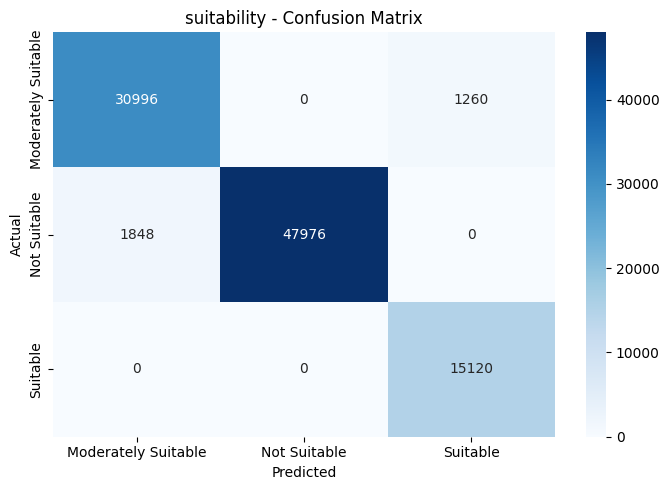

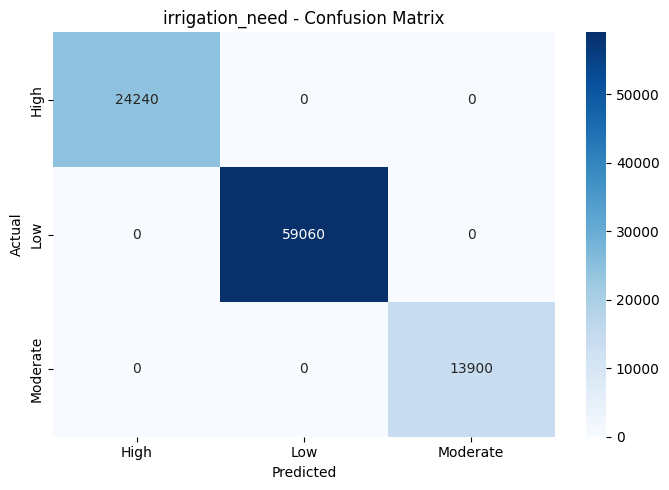

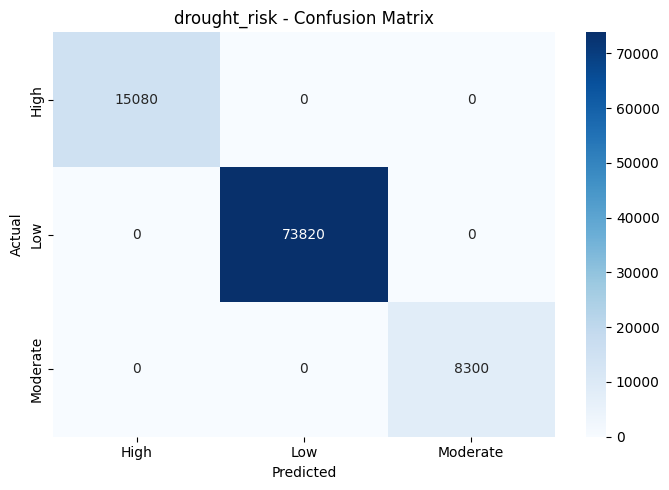

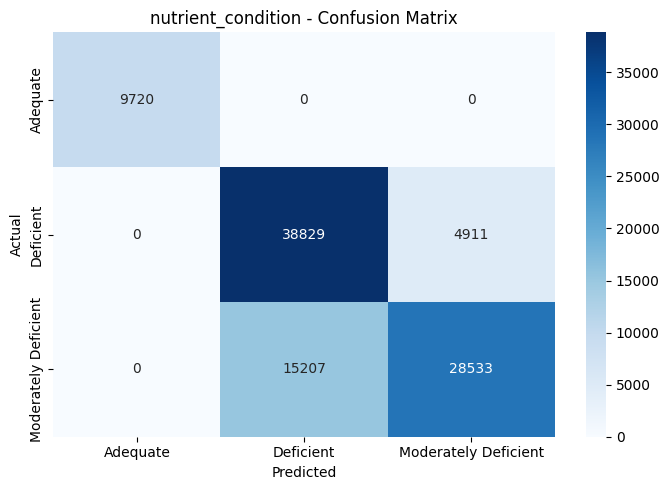

In [21]:
for i, target in enumerate(TARGETS):

    cm = confusion_matrix(
        Y_test.iloc[:, i],
        Y_pred[target]
    )

    plt.figure(figsize=(7, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=target_encoders[target].classes_,
        yticklabels=target_encoders[target].classes_
    )

    plt.title(f"{target} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

In [22]:
for target, estimator in zip(
    TARGETS,
    model.estimators_
):

    importance = pd.DataFrame({
        "Feature": FEATURES_FINAL,
        "Importance": estimator.feature_importances_
    })

    importance = importance.sort_values(
        "Importance",
        ascending=False
    )

    print("\n")
    print("=" * 60)
    print(target.upper())
    print("=" * 60)

    display(importance.head(15))



SUITABILITY


,Feature,Importance
3,ph,0.277909
4,annual_temperature_c,0.164545
16,temperature_range,0.161056
5,annual_rainfall_mm,0.122493
19,annual_rainfall_et0_ratio,0.088916
6,annual_et0_mm,0.052083
14,elevation,0.033564
21,npk_balance,0.014541
0,N,0.014291
7,monthly_temperature_c,0.013402




IRRIGATION_NEED


,Feature,Importance
13,water_balance_mm,0.200535
17,monthly_water_deficit,0.192583
18,rainfall_et0_ratio,0.163701
23,heat_water_stress_index,0.116438
8,monthly_rainfall_mm,0.091615
22,temperature_rainfall_interaction,0.058380
9,monthly_et0_mm,0.058024
12,precipitation_hours,0.042810
11,monthly_radiation,0.028796
7,monthly_temperature_c,0.017814




DROUGHT_RISK


,Feature,Importance
9,monthly_et0_mm,0.170250
7,monthly_temperature_c,0.125336
13,water_balance_mm,0.118770
17,monthly_water_deficit,0.111805
18,rainfall_et0_ratio,0.087152
23,heat_water_stress_index,0.080891
8,monthly_rainfall_mm,0.067985
22,temperature_rainfall_interaction,0.050704
11,monthly_radiation,0.043081
12,precipitation_hours,0.037884




NUTRIENT_CONDITION


,Feature,Importance
1,P,0.206358
0,N,0.204312
2,K,0.195102
21,npk_balance,0.166605
3,ph,0.114634
20,npk_total,0.112452
7,monthly_temperature_c,0.000039
10,monthly_wind_max_kmh,0.000037
9,monthly_et0_mm,0.000037
22,temperature_rainfall_interaction,0.000036


In [23]:
advisory_package = {
    "model": model,
    "imputer": imputer,
    "target_encoders": target_encoders,
    "features": FEATURES_FINAL,
    "targets": TARGETS,
    "version": "1.0"
}

joblib.dump(
    advisory_package,
    "mango_advisory_model.pkl"
)

print("Model saved successfully.")

Model saved successfully.


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

print("\n====================================")
print("MODEL EVALUATION")
print("====================================")

for i, target in enumerate(targets):


    y_true_target = Y_test.iloc[:, i]


    y_pred_target = Y_pred.iloc[:, i]

    print(f"\n{'=' * 50}")
    print(f"TARGET: {target.upper()}")
    print(f"{'=' * 50}")

    accuracy = accuracy_score(
        y_true_target,
        y_pred_target
    )

    precision = precision_score(
        y_true_target,
        y_pred_target,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_true_target,
        y_pred_target,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_true_target,
        y_pred_target,
        average="weighted",
        zero_division=0
    )

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")

    print("\nClassification Report:")

    print(
        classification_report(
            y_true_target,
            y_pred_target,
            zero_division=0
        )
    )


MODEL EVALUATION

TARGET: SUITABILITY
Accuracy : 0.9680
Precision: 0.9694
Recall   : 0.9680
F1 Score : 0.9682

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.96      0.95     32256
           1       1.00      0.96      0.98     49824
           2       0.92      1.00      0.96     15120

    accuracy                           0.97     97200
   macro avg       0.96      0.97      0.96     97200
weighted avg       0.97      0.97      0.97     97200


TARGET: IRRIGATION_NEED
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1 Score : 1.0000

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     24240
           1       1.00      1.00      1.00     59060
           2       1.00      1.00      1.00     13900

    accuracy                           1.00     97200
   macro avg       1.00      1.00      1.00     97200
weighted avg       1.00      1.00    